# Nhóm 8
Demo này sử dụng model GPT-2 từ thư viện Hugging Face Transformers để minh hoạ trực quan cách các thành phần trong kiến trúc Transformer hoạt động trong bài toán language modeling. Cụ thể, notebook này lần lượt trình bày và demo một số mục trong sách theo đúng thứ tự như sau:
- 8.4 The Input
- 8.1 Attention
- 8.1.1 Multi-head Attention
- 8.3 Masked Attention (mục con)
- 8.5 The Language Modeling Head
- 8.6 Sampling
- 8.9 In-context Learning

# 8.4 The input: embeddings for token and position

Minh hoạ bước đầu vào của Transformer, cụ thể là cách text được chuyển thành token IDs trước khi đi vào embedding layer.
- Ta thực hiện bằng cách dùng tokenizer để tách câu thành các tokens.
- Sau đó chuyển các tokens này thành các số nguyên (token IDs), đây chính là dữ liệu mà embedding layer sẽ nhận vào để ánh xạ thành vector.
- Cuối cùng, ta decode lại từ token IDs về text để kiểm tra quá trình tokenization hoạt động đúng.

In [ ]:
from transformers import AutoTokenizer

# Load tokenizer (GPT-2)
tokenizer = AutoTokenizer.from_pretrained("gpt2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
text = "The chicken didn’t cross the road because it was tired"
# Tokenize
tokens = tokenizer.tokenize(text)
# Tokens → IDs
token_ids = tokenizer.convert_tokens_to_ids(tokens)
# Decode lại
decoded_text = tokenizer.decode(token_ids)

In [ ]:
print("Original text:")
print(text)

print("\nTokens:")
print(tokens)

print("\nToken IDs:")
print(token_ids)

print("\nDecoded text:")
print(decoded_text)

Original text:
The chicken didn’t cross the road because it was tired

Tokens:
['The', 'Ġchicken', 'Ġdidn', 'âĢ', 'Ļ', 't', 'Ġcross', 'Ġthe', 'Ġroad', 'Ġbecause', 'Ġit', 'Ġwas', 'Ġtired']

Token IDs:
[464, 9015, 1422, 447, 247, 83, 3272, 262, 2975, 780, 340, 373, 10032]

Decoded text:
The chicken didn’t cross the road because it was tired


# 8.1 Attention

Phần này minh hoạ cơ chế attention trong Transformer, tức là cách mỗi token xây dựng biểu diễn của mình bằng cách “chú ý” đến các token khác trong câu.
- Ta thực hiện bằng cách đưa một câu vào model pretrained.
- Lấy attention weights từ layer cuối.
- Sau đó vẽ heatmap để hiển thị mức độ mỗi token (query) đang tập trung vào các token khác (key), qua đó thể hiện trực tiếp cách attention kết hợp thông tin ngữ cảnh.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# Load tokenizer + model (GPT-2)
tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2", output_attentions=True)

model.eval()

text = "The chicken didn’t cross the road because it was tired"

# Encode
inputs = tokenizer(text, return_tensors="pt")

# Forward pass + lấy attention
with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

# Lấy attention của layer cuối
attentions = outputs.attentions  # tuple: (num_layers, batch, num_heads, seq_len, seq_len)
last_layer_attn = attentions[-1][0]  # (num_heads, seq_len, seq_len)

# Lấy token list
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

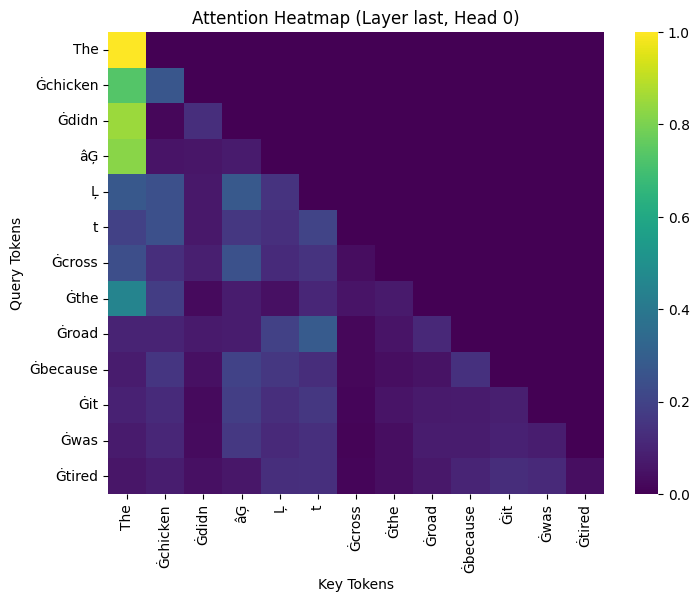

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chọn 1 head để visualize
head = 0
attn_matrix = last_layer_attn[head].cpu().numpy()

plt.figure(figsize=(8, 6))
sns.heatmap(attn_matrix, xticklabels=tokens, yticklabels=tokens, cmap="viridis")

plt.title(f"Attention Heatmap (Layer last, Head {head})")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

# 8.1.1 Multi-head Attention

Phần này mở rộng attention thành multi-head attention, nơi nhiều attention heads cùng hoạt động song song để học các mối quan hệ khác nhau trong câu.
- Ta thực hiện bằng cách lấy attention weights của nhiều head trong cùng một layer.
- Sau đó vẽ nhiều heatmap tương ứng với từng head để quan sát sự khác biệt, qua đó thấy rằng mỗi head đang tập trung vào những pattern khác nhau của dữ liệu.

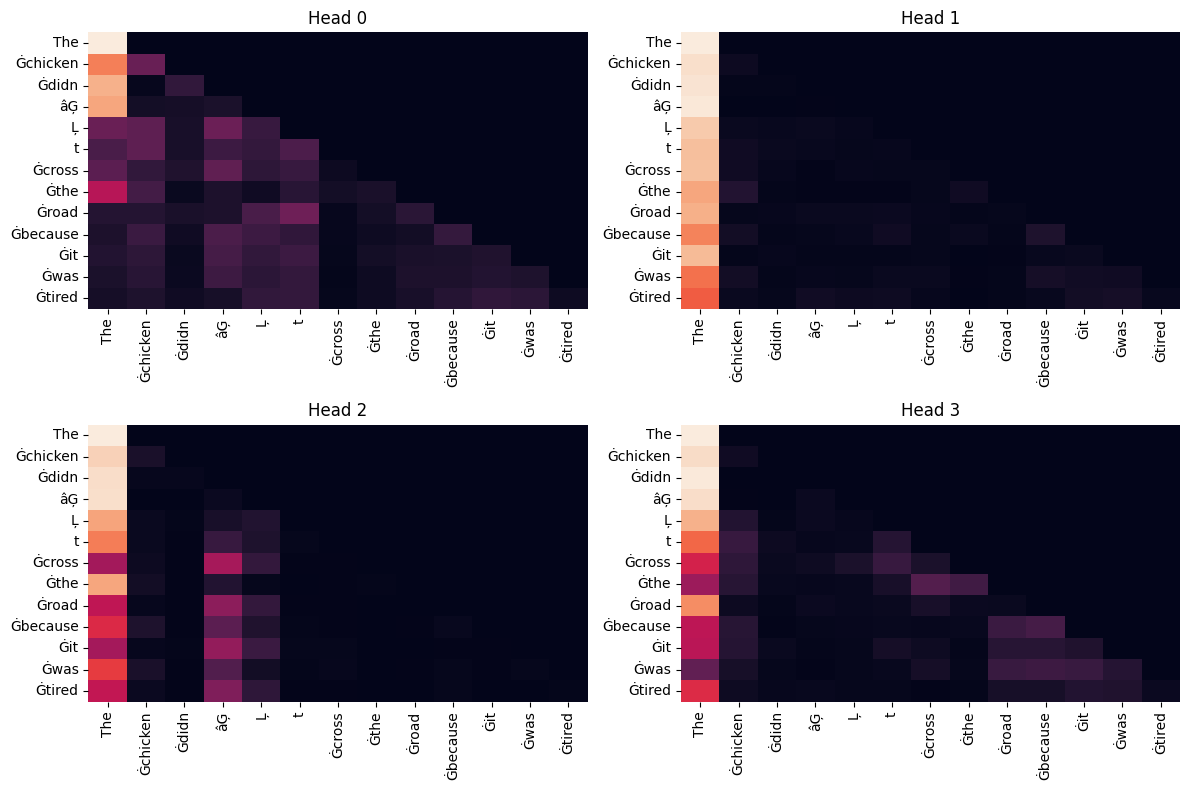

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_heads = last_layer_attn.shape[0]

plt.figure(figsize=(12, 8))

for i in range(min(4, num_heads)):
    plt.subplot(2, 2, i+1)
    sns.heatmap(last_layer_attn[i].cpu().numpy(),
                xticklabels=tokens,
                yticklabels=tokens,
                cbar=False)
    plt.title(f"Head {i}")

plt.tight_layout()
plt.show()

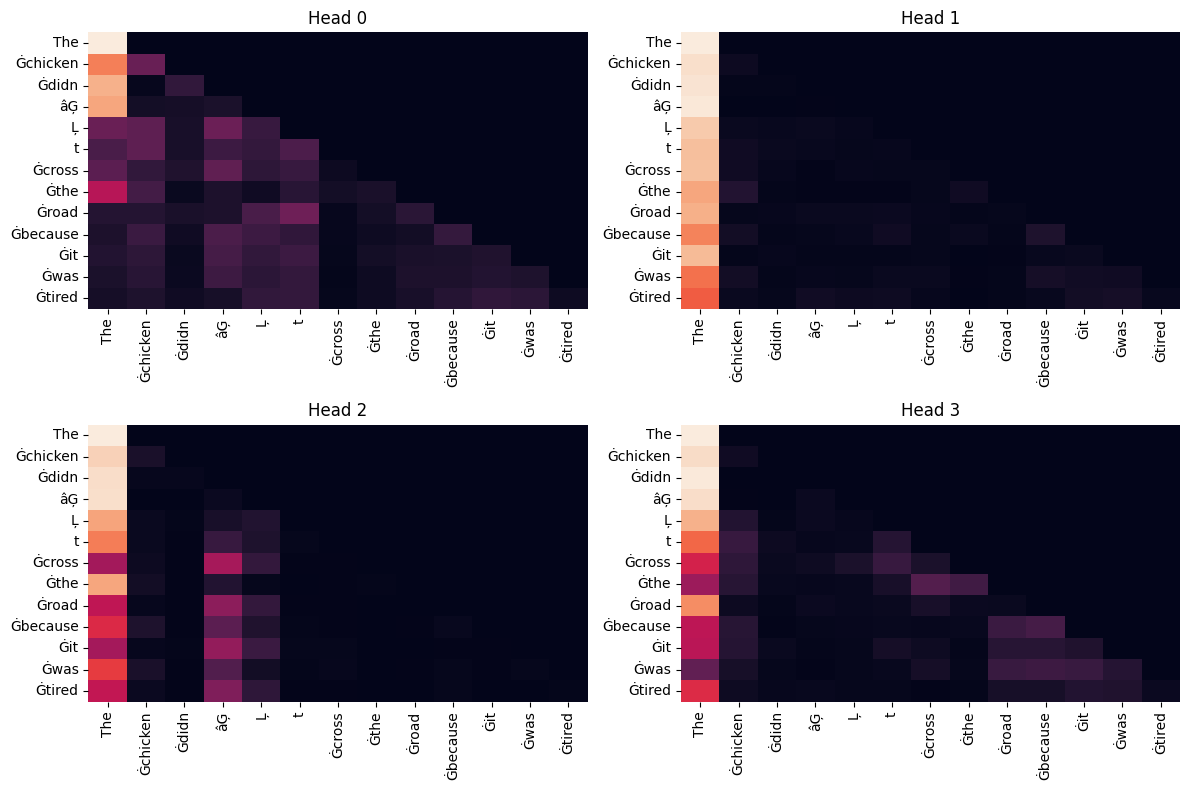

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_heads = last_layer_attn.shape[0]

plt.figure(figsize=(12, 8))

for i in range(min(4, num_heads)):
    plt.subplot(2, 2, i+1)
    sns.heatmap(last_layer_attn[i].cpu().numpy(),
                xticklabels=tokens,
                yticklabels=tokens,
                cbar=False)
    plt.title(f"Head {i}")

plt.tight_layout()
plt.show()

## Nhận xét
- Mỗi head học một kiểu attention khác nhau

# 8.3 Masked Attention

Phần này minh hoạ cơ chế masked attention trong Transformer dùng cho language modeling, đảm bảo mỗi token chỉ được phép nhìn về các token phía trước mà không được nhìn tương lai.
- Ta thực hiện bằng cách lấy attention matrix từ model.
- Vẽ heatmap và quan sát cấu trúc của nó, trong đó các giá trị tương ứng với việc nhìn về các token phía sau bị triệt tiêu, thể hiện rõ ràng cơ chế causal masking.

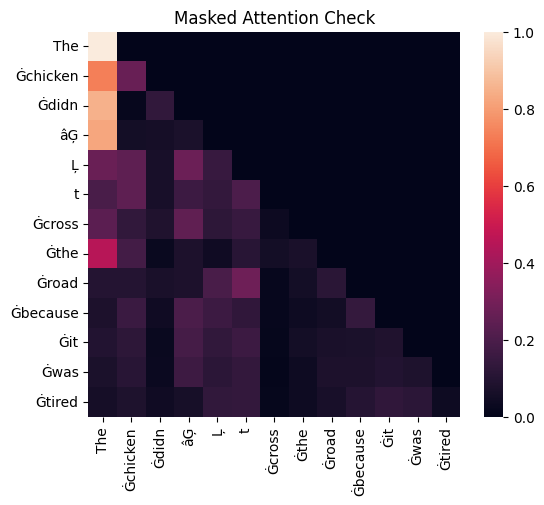

In [ ]:
import numpy as np

head = 0
attn = last_layer_attn[head].cpu().numpy()

plt.figure(figsize=(6, 5))
sns.heatmap(attn, xticklabels=tokens, yticklabels=tokens)
plt.title("Masked Attention Check")
plt.show()

# 8.5 Language Modeling Head

Phần này minh hoạ language modeling head, tức là cách Transformer chuyển biểu diễn ẩn của token cuối thành dự đoán token tiếp theo.
- Ta thực hiện bằng cách đưa một câu vào model.
- Lấy logits tại vị trí token cuối cùng.
- Sau đó chọn các token có xác suất cao nhất, qua đó thấy được cách model ánh xạ từ vector biểu diễn sang phân phối xác suất trên toàn bộ vocabulary.

In [ ]:
text = "The cat is"

inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
last_token_logits = logits[0, -1]

# top 10 dự đoán
top_k = 10
top_k_indices = torch.topk(last_token_logits, top_k).indices

predicted_tokens = [tokenizer.decode([idx]) for idx in top_k_indices]

print("Input:", text)
print("\nTop predictions:")
for t in predicted_tokens:
    print(t)

Input: The cat is

Top predictions:
 a
 still
 not
 now
 in
 the
 also
 so
 very
 about


# 8.6 Sampling

Phần này minh hoạ các phương pháp sampling trong quá trình sinh text từ Transformer, cho thấy cách chuyển từ phân phối xác suất sang chuỗi output cụ thể.
- Ta thực hiện bằng cách sử dụng cùng một prompt và sinh text bằng các phương pháp khác nhau như greedy, top-k và top-p, từ đó quan sát sự khác biệt trong kết quả sinh ra do cách chọn token khác nhau.

In [ ]:
from transformers import set_seed

set_seed(42)

prompt = "Once upon a time"

inputs = tokenizer(prompt, return_tensors="pt")

# Greedy
greedy_output = model.generate(**inputs, max_length=30)

# Top-k
topk_output = model.generate(**inputs, max_length=30, do_sample=True, top_k=50)

# Top-p
topp_output = model.generate(**inputs, max_length=30, do_sample=True, top_p=0.9)

print("Greedy:\n", tokenizer.decode(greedy_output[0]))
print("\nTop-k:\n", tokenizer.decode(topk_output[0]))
print("\nTop-p:\n", tokenizer.decode(topp_output[0]))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Greedy:
 Once upon a time, the world was a place of great beauty and great danger. The world was a place of great danger, and the world was

Top-k:
 Once upon a time, there was a certain person in this world who believed, that if one wished to be a man it would be better to go

Top-p:
 Once upon a time he said he was sorry and told me not to. Then he said: 'We'll never give you anything in exchange for being


## Nhận xét
- Greedy: ổn định, ít đa dạng
- Top-k / Top-p: đa dạng hơn

# 8.9 In-context Learning

Phần này minh hoạ khả năng in-context learning của Transformer, tức là khả năng suy luận dựa trên các ví dụ có sẵn trong prompt mà không cần cập nhật tham số.
- Ta thực hiện bằng cách cung cấp một chuỗi ví dụ (ví dụ như dịch từ tiếng Anh sang tiếng Pháp) ngay trong input.
- Sau đó yêu cầu model dự đoán phần tiếp theo, qua đó thể hiện cách model tận dụng ngữ cảnh để thực hiện nhiệm vụ mới.

In [ ]:
prompt = """Translate English to French:
cat → chat
dog → chien
fish →"""

inputs = tokenizer(prompt, return_tensors="pt")

output = model.generate(**inputs, max_length=50)

print(tokenizer.decode(output[0]))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Translate English to French:
cat → chat
dog → chien
fish → fish
fish → fish
fish → fish
fish → fish
fish → fish
fish → fish
fish → fish
fish → fish
fish →
